In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

In [31]:
df=pd.read_excel("../data/raw/online_retail_II.xlsx")

In [32]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [33]:
df.shape

(525461, 8)

In [34]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [35]:
df = df.dropna(subset=["Customer ID"])

In [36]:
df["Customer ID"] = df["Customer ID"].astype(int)

In [37]:
df = df[df["Quantity"] > 0]

In [38]:
df = df[df["Price"] > 0]

In [39]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df["Revenue"] = df["Quantity"] * df["Price"]

In [40]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


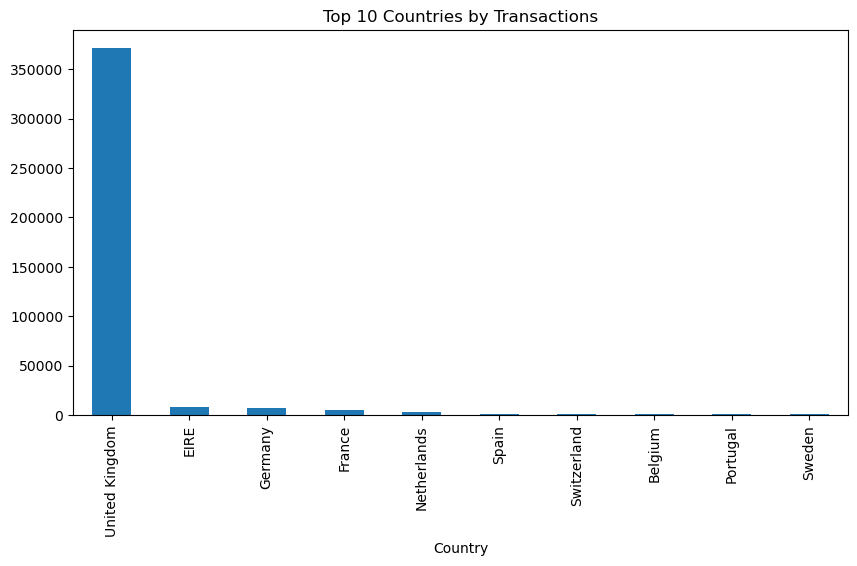

In [41]:
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Transactions')
plt.show()

In [42]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_df = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

customer_df.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
customer_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [43]:
features = customer_df[["Recency", "Frequency", "Monetary"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

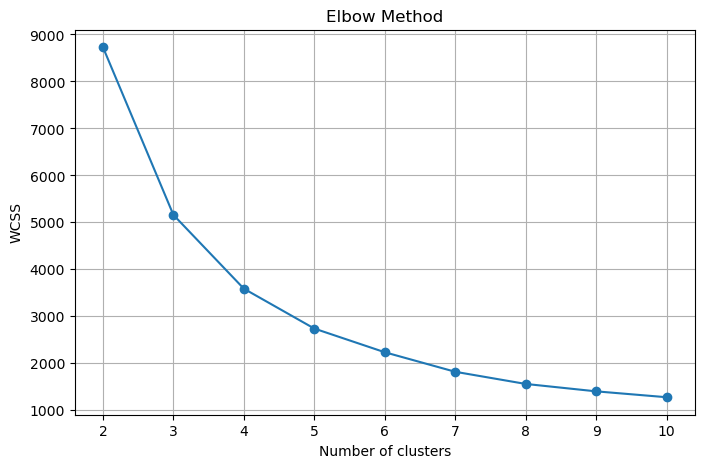

In [44]:
wcss = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [45]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,165,11,372.86,1
1,12347,3,2,1323.32,0
2,12348,74,1,222.16,0
3,12349,43,3,2671.14,0
4,12351,11,1,300.93,0


In [46]:
cluster_summary = customer_df.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.07,4.43,1710.80
1,242.98,1.66,596.88
2,5.60,113.60,215543.67
3,14.27,46.03,28018.43


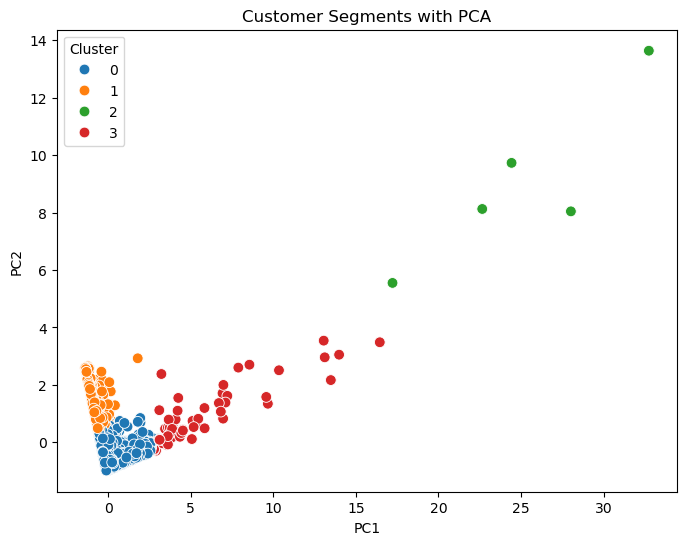

In [47]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["Cluster"] = customer_df["Cluster"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=60)
plt.title("Customer Segments with PCA")
plt.show()

In [48]:
customer_df.to_csv("clustered_customers.csv", index=False)
cluster_summary.to_csv("cluster_summary.csv", index=False)

In [49]:
# Example manual labeling after reviewing cluster_summary
segment_map = {
    0: "At Risk",
    1: "Loyal Customers",
    2: "High Value",
    3: "Champions"
}

customer_df["Segment"] = customer_df["Cluster"].map(segment_map)
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,165,11,372.86,1,Loyal Customers
1,12347,3,2,1323.32,0,At Risk
2,12348,74,1,222.16,0,At Risk
3,12349,43,3,2671.14,0,At Risk
4,12351,11,1,300.93,0,At Risk
